In [1]:
# This is a computer program code, used for Physics Balmer Series experiment to analyse and visualise the collected data, with the main goal of determining the Rydberg constant
# Valen Lebepe
# 04 September 2025

In [2]:
# Importing relevant python libraries
import pandas as pd    # importing pandas
import numpy as np     # importing numpy
import matplotlib.pyplot as plt       # importing matplotlib.pyplot for non-interactve plots
from scipy.optimize import curve_fit  # importing the curve fitting module from SciPy
import plotly.express as px           # Importing Plotly for interactive Plots


In [3]:
# Importing in the data/ reading the DataFrame
df = pd.read_csv("Hydrogen[4100-4140].csv", sep="," ,skiprows= 14, names =["wavelength", "counts"])                  # data
df_background = pd.read_csv("Background [4000 - 5000].csv", sep =",", skiprows=14, names =["wavelength", "counts"])  # data
offset = [20.36, 0.016]    # Calibatrion offset value (Its best value, and its uncertainty)



In [4]:
# Cleaning and filtering the data

# Converting the columns to numerics
df["wavelength"]= pd.to_numeric(df["wavelength"], errors="coerce")
df["counts"]= pd.to_numeric(df["counts"], errors="coerce")

df["wavelength"]=df["wavelength"]-offset[0]   # Calibrating the data

df_background["wavelength"]= pd.to_numeric(df_background["wavelength"], errors="coerce")
df_background["counts"]= pd.to_numeric(df_background["counts"], errors="coerce")

# Drop any rows that have missing or invalid values
df_background = df_background.dropna()
df = df.dropna()



In [5]:
# Visualizing the raw data data

# Using Plotly
fig1 =px.scatter(df, x="wavelength", y = "counts", title="The Spectrum of a HeNe Laser",labels = {"wavelength":"λ[Å]", "counts":"counts"})
fig1.show()
fig2 = px.scatter(df_background, x="wavelength", y="counts", title="The Background Emission", labels ={"wavelength":"λ[Å]", "counts":"counts"})
fig2.show()




In [6]:
# Filtering out the data and picking up an area of interest
filtered_df = df[(df["wavelength"]>= 4090) & (df["wavelength"]<=4108)]
filtered_df_background = df_background[(df_background["wavelength"]>= 4090) & (df_background["wavelength"]<=4108)]

print(f"the length of the background data counts is:{len(filtered_df_background["counts"])}")
print(f"the length of the data is counts is:{len(filtered_df["counts"])}")


the length of the background data counts is:19
the length of the data is counts is:90


In [7]:
# Interpolating the background
background_counts= np.interp(filtered_df["wavelength"], filtered_df_background["wavelength"], filtered_df_background["counts"])
print(f"the length of the background data counts is:{len(background_counts)}")
print(f"the length of the data is counts is:{len(filtered_df["counts"])}")



the length of the background data counts is:90
the length of the data is counts is:90


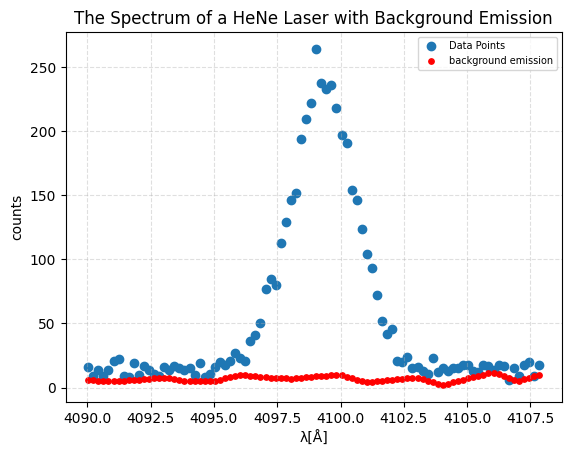

In [8]:
# Visualising the filtered data
fig3 = px.scatter(filtered_df, x="wavelength", y="counts", title="The Spectrum of a HeNe Laser", labels = {"wavelength":"λ[Å]", "counts":"counts"})
fig3.show()
fig4 = px.scatter(x= filtered_df["wavelength"], y=background_counts, title="The Background Emission", labels = {"x":"λ[Å]", "y":"counts"})
fig4.show()

# Ploting the Background on the same axis with the sepctrum using Matplotlib
plt.scatter(filtered_df["wavelength"], filtered_df["counts"], label ="Data Points")
plt.scatter(filtered_df["wavelength"], background_counts, color="red", s= 15, label="background emission")
plt.grid(True, linestyle ="--" ,alpha=0.4)
plt.title("The Spectrum of a HeNe Laser with Background Emission")
plt.xlabel("λ[Å]")
plt.ylabel("counts")
plt.legend(fontsize= 7)
#plt.savefig("Laser_background_spectrum.png")    # Saving the results as png
plt.show()


In [9]:
# Subtracting Background from Data
filtered_df["counts"] = filtered_df["counts"] - background_counts


/tmp/ipython-input-1425469442.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



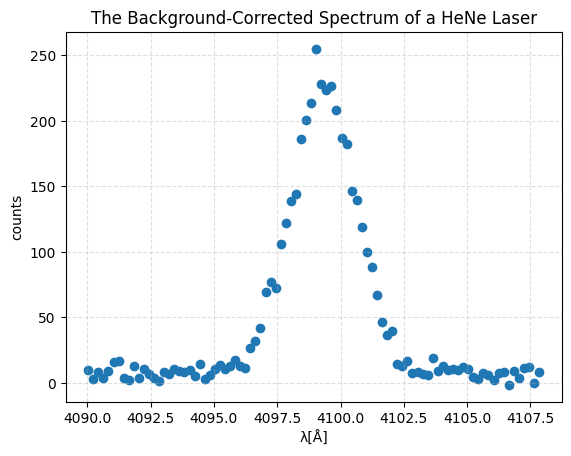

In [10]:
# Visualising the results
plt.scatter(filtered_df["wavelength"], filtered_df["counts"])
plt.grid(True, linestyle ="--" ,alpha=0.4)
plt.title("The Background-Corrected Spectrum of a HeNe Laser")
plt.xlabel("λ[Å]")
plt.ylabel("counts")
#plt.savefig("background_Corrected_Spectrum.png")
plt.show()


The Centroid is:4099.313 ± 0.027 Å


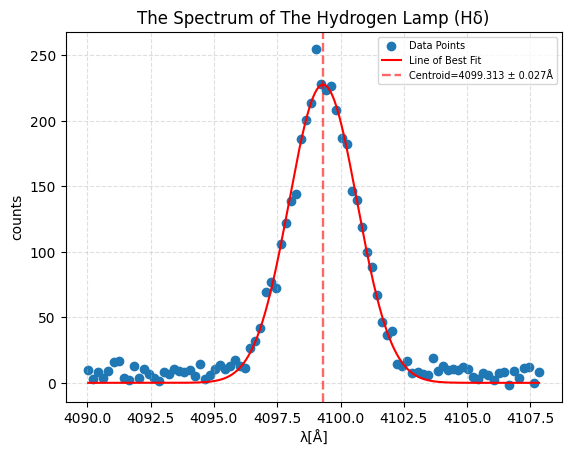

In [11]:
##### Fittng in the Model of best Fit to the data #####

# Defining the model function
def gaussian (x,mu, sigma, a): # the data can be best modeled by a gaussian
  return  a*(np.exp(-1*(x-mu)**2/(2*sigma**2)))

# mu is the mean (centroid) and the centre of the distribution. It is the **x value** where the function is at its maximum
# sigma is the parameter that determines how spread out or concentrated the curve is. It is the standard deviation.
# a a is the amplitude parameter.It's a scaling factor that controls the height of the Gaussian curve's peak.

# Making initial guesses
p0 = [4099.44, 10, 265]

# Executing the fit
popt, pcov =curve_fit(gaussian, filtered_df["wavelength"], filtered_df["counts"], p0)

# Printing out the Relevent Optimal parameter (centroid)
perr = np.sqrt(np.diag(pcov))   # Uncertainty of the parameters

# Calibrating the Uncertainty of the mean
perr[0] = np.sqrt((perr[0])**2 + (offset[1])**2)   # Calibrated Uncertainty of the mean
print(f"The Centroid is:{popt[0]:.3f} ± {perr[0]:.3f} Å")

# Visualising the model
x_fit = np.linspace(min(filtered_df["wavelength"]), max(filtered_df["wavelength"]), 10000)
y_fit = np.array(gaussian(x_fit,popt[0], popt [1], popt [2]))

# Ploting the data and the model
plt.scatter(filtered_df["wavelength"], filtered_df["counts"], label ="Data Points")
plt.plot(x_fit,y_fit, "r", label = "Line of Best Fit")
plt.axvline(x= popt[0],color ="red",label =f'Centroid={popt[0]:.3f} ± {perr[0]:.3f}Å',  linestyle ="--", alpha =0.6, linewidth =1.7)
plt.grid(True, linestyle ="--" ,alpha=0.4)

plt.title(f"The Spectrum of The Hydrogen Lamp (Hδ)")
plt.xlabel("λ[Å]")
plt.ylabel("counts")
plt.legend(fontsize= 7)
#plt.savefig("Hδ spectrum.png")
plt.show()


In [12]:
# Importing in the data/ reading the DataFrame
df1 = pd.read_csv("Hydrogen[4100-4140].csv", sep="," ,skiprows= 14, names =["wavelength", "counts"])   # data
df2 = pd.read_csv("Hydrogen[4340-4370].csv", sep="," ,skiprows= 14, names =["wavelength", "counts"])   # data
df3 = pd.read_csv("Hydrogen[4862-4895].csv", sep="," ,skiprows= 14, names =["wavelength", "counts"])   # data
df4 = pd.read_csv("Hydrogen[6550-6600].csv", sep="," ,skiprows= 68, names =["wavelength", "counts"])   # data


In [13]:
# Joining the data to once large data frame
df=pd.concat([df1,df2,df3,df4], ignore_index=True)

In [14]:
# Cleaning and filtering the data

# Converting the columns to number
df["wavelength"]= pd.to_numeric(df["wavelength"], errors="coerce")
df["counts"]= pd.to_numeric(df["counts"], errors="coerce")

df["wavelength"]=df["wavelength"]-offset[0]    # Calibrating the data

# Drop any rows that have missing or invalid values
df = df.dropna()


/tmp/ipython-input-2779361014.py:7: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



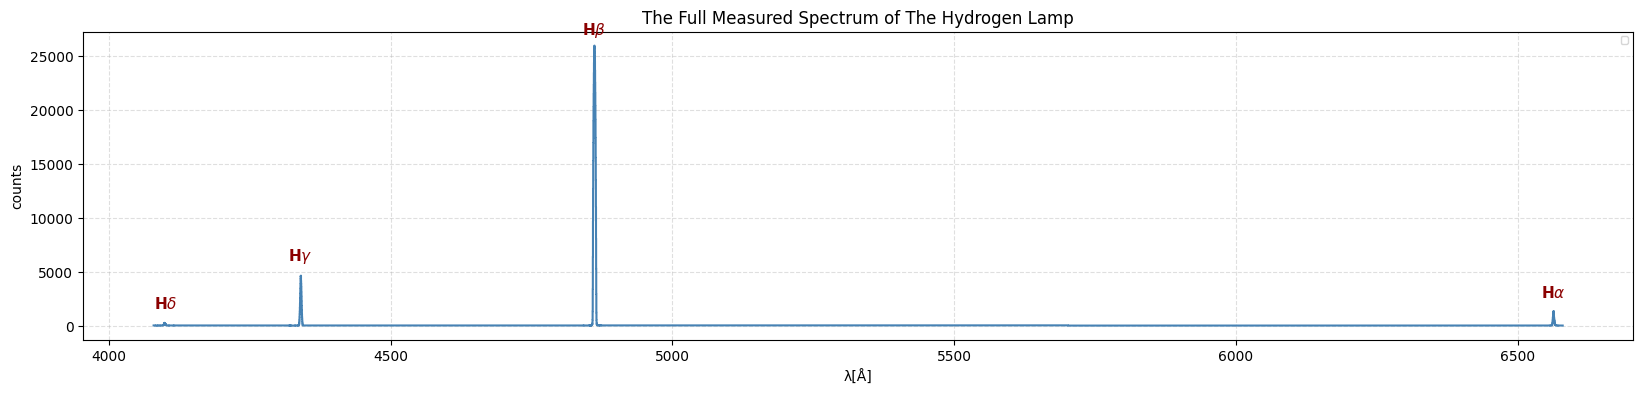

In [15]:
# Visualising the data
plt.figure(figsize=(20, 4))
plt.step(df['wavelength'],df['counts'],where='mid',color='steelblue',linewidth=1.5)
plt.title("The Full Measured Spectrum of The Hydrogen Lamp")
plt.xlabel("λ[Å]")
plt.ylabel("counts")
plt.legend(fontsize= 7)
plt.grid(True, linestyle ="--" ,alpha=0.4)

# Labeling the peaks on the plot
peaks = {r'H$\alpha$': 6562.8,r'H$\beta$': 4861.3,r'H$\gamma$': 4340.5,r'H$\delta$': 4101.7}

y_offset = max(df['counts']) * 0.05

for label, wavelength in peaks.items():
    idx = (abs(df['wavelength'] - wavelength)).idxmin()
    y_value = df.loc[idx, 'counts']

    plt.text(wavelength, y_value + y_offset, label, ha='center', va='bottom',fontsize=11, fontweight='bold', color='darkred')

#plt.savefig("The Full Measured Spectrum of The Hydrogen Lamp.png")
plt.show()




In [16]:
# Defining the data to suit the Rydberg formula:

y_measured = np.array([6563.415, 4861.873, 4340.866, 4099.313])    # this is a list of the dataset
y_measured = y_measured * 1e-10   # Converting the data from angstrongs to metres
y = 1/y_measured     # This is the array of y values used for the Rydberg formula linear fitting
dy_dy_measured = np.abs(-1/(y_measured)**2)
y_error_measured = np.array([0.023, 0.041, 0.017, 0.027])   # This is the uncertainties of each data point
y_error = (dy_dy_measured)*(y_error_measured)      # This is the uncertainty for the y values used in Rydberg formula fitting
y_error = (dy_dy_measured)*(y_error_measured)*(1e-10)      # This is the uncertainty for the y values used in Rydberg formula fitting converted to metres
n = np.array([3, 4, 5, 6]) # These are the  values of the energy levels
x = 1/(2**2)-1/(n**2)      # This is the array of x values used for the Rydberg formula linear fitting

The Rydberg constant is:10975956.882 ± 125.907 Å
The Y-intercept is:-873.172 ± 21.060 Å


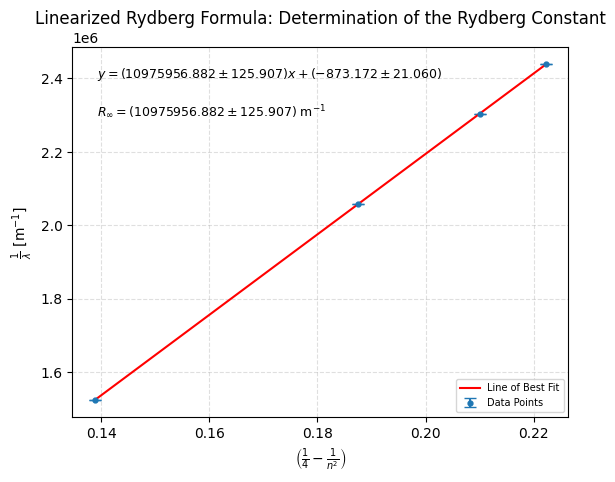

In [17]:
# Defining the model function
def linear(x,m,c):
  return m*x + c

# Fitting the model to the data
popt, pcov = curve_fit(linear, x, y, sigma=y_error, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))   # Uncertainty of the parameters

# Printing out the Relevent Optimal parameter (Gradient==Rydberg Contant)
print(f"The Rydberg constant is:{popt[0]:.3f} ± {perr[0]:.3f} Å")
print(f"The Y-intercept is:{popt[1]:.3f} ± {perr[1]:.3f} Å")

# Visualising the model
x_fit = np.linspace(min(x), max(x), 10000)
y_fit = np.array(linear(x_fit,popt[0], popt [1]))

# Ploting the data and the model
plt.errorbar(x, y, yerr=y_error, fmt='o',capsize=4.5, markersize=3.5, label ="Data Points")   # Plotting the errorbars
plt.plot(x_fit,y_fit, "r", label = "Line of Best Fit")    # Ploting the line of best fit
plt.grid(True, linestyle ="--" ,alpha=0.4)
plt.title("Linearized Rydberg Formula: Determination of the Rydberg Constant")
plt.xlabel(r'$\left(\frac{1}{4} - \frac{1}{n^{2}}\right)$')
plt.ylabel(r'$\frac{1}{\lambda}$ [m$^{-1}$]')
plt.legend(fontsize= 7)

# Add equation and result text box
equation_text = f'$y = ({popt[0]:.3f} \\pm {perr[0]:.3f})x + ({popt[1]:.3f} \\pm {perr[1]:.3f})$'
rydberg_text = f'$R_\\infty = ({popt[0]:.3f} \\pm {perr[0]:.3f})$ m$^{{-1}}$'

plt.text(0.05, 0.95, equation_text, transform=plt.gca().transAxes, fontsize=9, va='top')
plt.text(0.05, 0.85, rydberg_text, transform=plt.gca().transAxes, fontsize=9, va='top')

#plt.savefig("Rydberg Formula.png")
plt.show()